In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import gc
import io
import os
from itertools import combinations

from IPython.display import display

pd.set_option('display.max_columns', 99)
pd.set_option('display.max_rows', 200)

pd.reset_option('display.float_format')
pd.set_option('display.max_colwidth', None)

from config import ROOT  # lib này được khởi tạo ban đầu dự án

import helpers.view as view
import helpers.EDA as EDA
import modules.utils as utils

importlib.reload(view)
importlib.reload(EDA)
importlib.reload(utils)

from helpers.cache_clear import cache_clear

In [2]:
get_pickle = utils.get_pickle
get_pickles = utils.get_pickles

In [3]:
_keep_vars = set(globals().keys())  # lưu biến gốc

# prev application

In [24]:
prev = get_pickles("prev", ['SK_ID_CURR', "SK_ID_PREV", 'NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', "DAYS_DECISION", "interest_rate", "CNT_PAYMENT", "NAME_TYPE_SUITE", "WEEKDAY_APPR_PROCESS_START",	"HOUR_APPR_PROCESS_START"])

In [5]:
train = get_pickle("train")
test = get_pickle("test")

In [6]:
train_id = get_pickle("train")["SK_ID_CURR"]
test_id = get_pickle("test")["SK_ID_CURR"]

In [7]:
prev.loc[prev["SK_ID_CURR"].isin(train_id), "data"] = 1
prev.loc[prev["SK_ID_CURR"].isin(test_id), "data"] = 0

In [8]:
prev.head(10)

,SK_ID_CURR,SK_ID_PREV,NAME_CONTRACT_TYPE,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_DECISION,interest_rate,CNT_PAYMENT,data
0,100001,1369693,Consumer loans,23787.0,3951.000,24835.50,-1740,0.067887,8.0,0.0
1,100002,1038818,Consumer loans,179055.0,9251.775,179055.00,-606,0.017982,24.0,1.0
2,100003,2396755,Consumer loans,68053.5,6737.310,68809.50,-2341,0.027553,12.0,1.0
3,100003,2636178,Consumer loans,348637.5,64567.665,337500.00,-828,0.030984,6.0,1.0
4,100003,1810518,Cash loans,1035882.0,98356.995,900000.00,-746,0.020672,12.0,1.0
5,100004,1564014,Consumer loans,20106.0,5357.250,24282.00,-815,0.025987,4.0,1.0
6,100005,2495675,Consumer loans,40153.5,4813.200,44617.50,-757,0.060906,12.0,0.0
7,100005,1857999,Cash loans,NaN,NaN,NaN,-315,NaN,NaN,0.0
8,100006,2299329,Consumer loans,24219.0,2482.920,26912.34,-617,0.033413,12.0,1.0
9,100006,1020698,Cash loans,481495.5,39954.510,454500.00,-438,0.046131,18.0,1.0


# prev của test chứa các khoản vay ở thời điểm tương lai hơn so với prev của test (lệch pha khoảng 150 đến 200 ngày)

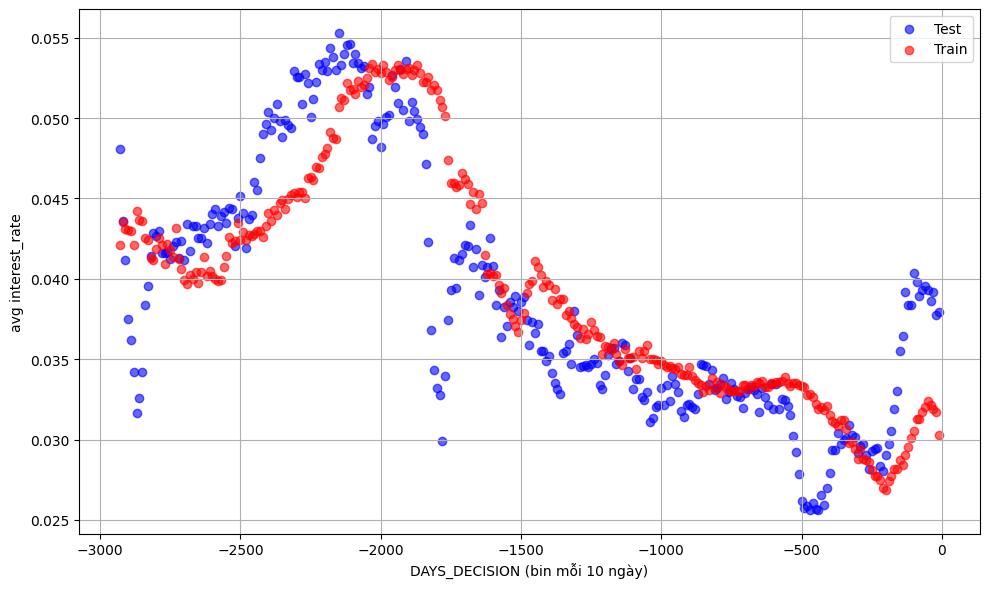

In [9]:
prev["DAYS_DECISION_BIN"] = (prev["DAYS_DECISION"] // 10) * 10
avg_interest = prev.groupby(["data", "DAYS_DECISION_BIN"])["interest_rate"].mean().reset_index()
plt.figure(figsize=(10, 6))

colors = {0: 'blue', 1: 'red'}
labels = {0: 'Test', 1: 'Train'}

for d in avg_interest["data"].unique():
    subset = avg_interest[avg_interest["data"] == d]
    plt.scatter(subset["DAYS_DECISION_BIN"], subset["interest_rate"],
                color=colors[d], label=labels[d], alpha=0.6)

plt.xlabel("DAYS_DECISION (bin mỗi 10 ngày)")
plt.ylabel("avg interest_rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# tham khảo https://www.kaggle.com/c/home-credit-default-risk/discussion/64784

# giả thiết

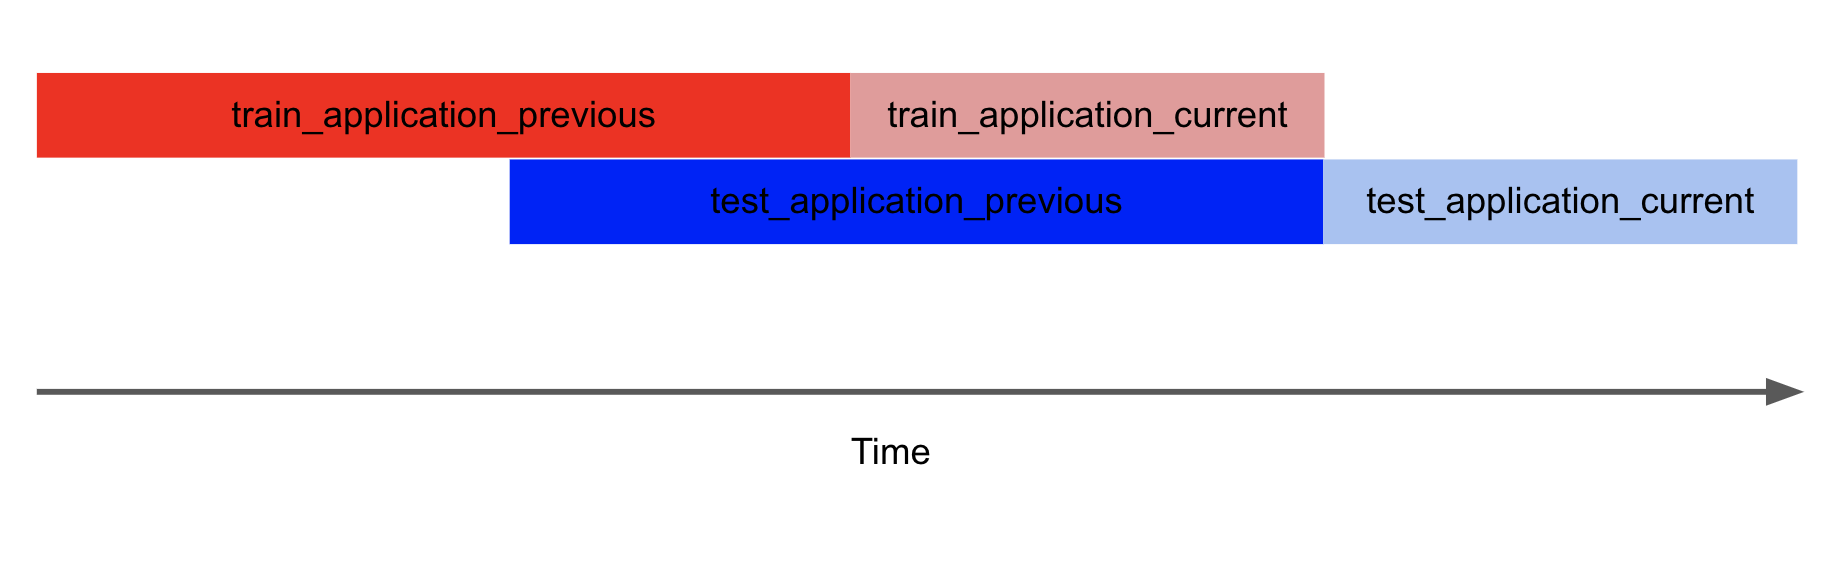

# dùng stacking lightgbm + kfold để predict CNT_PAYMENT cho application train test

In [10]:
import lightgbm as lgb
import multiprocessing
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [11]:
SEED = 71
param = {
    'objective': 'regression',       
    'metric': 'rmse',                
    'learning_rate': 0.05,
    'max_depth': -1,
    'num_leaves': 255,
    'max_bin': 255,
    'colsample_bytree': 0.5,
    'subsample': 0.5,
    'nthread': multiprocessing.cpu_count(),
    'bagging_freq': 1,
    'seed': SEED
}

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

In [13]:
prev=prev.dropna(subset=['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'CNT_PAYMENT'])

In [14]:
prev[prev.isna().any(axis=1)]

,SK_ID_CURR,SK_ID_PREV,NAME_CONTRACT_TYPE,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_DECISION,interest_rate,CNT_PAYMENT,data,DAYS_DECISION_BIN


In [15]:
X = prev.drop(["SK_ID_CURR", "SK_ID_PREV", "interest_rate", "data", "CNT_PAYMENT", 'DAYS_DECISION', 'DAYS_DECISION_BIN'], axis=1)
y = prev["CNT_PAYMENT"]

In [16]:
for col in prev.select_dtypes(include=['object']).columns:
    prev[col] = prev[col].astype('category')

In [17]:
# one hot encode
# X = pd.get_dummies(X, columns=["NAME_CONTRACT_TYPE"], drop_first=True).astype(int)


# label encode
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
X['NAME_CONTRACT_TYPE'] = label_encoder.fit_transform(X['NAME_CONTRACT_TYPE'])

In [18]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
dtrain = lgb.Dataset(X_train, y_train)
dval = lgb.Dataset(X_val, y_val)
model = lgb.train(param, dtrain, valid_sets=[dval],
                    num_boost_round=5000,
                    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

preds = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, preds))
print(f"Single LightGBM model RMSE: {rmse:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001907 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 767
[LightGBM] [Info] Number of data points in the train set: 922352, number of used features: 4
[LightGBM] [Info] Start training from score 18.076401
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 3.57473
[200]	valid_0's rmse: 3.02845
[300]	valid_0's rmse: 2.88912
[400]	valid_0's rmse: 2.80357
[500]	valid_0's rmse: 2.75074
[600]	valid_0's rmse: 2.69925
[700]	valid_0's rmse: 2.66166
[800]	valid_0's rmse: 2.62591
[900]	valid_0's rmse: 2.59954
[1000]	valid_0's rmse: 2.57595
[1100]	valid_0's rmse: 2.55116
[1200]	valid_0's rmse: 2.5288
[1300]	valid_0's rmse: 2.50915
[1400]	valid_0's rmse: 2.49468
[1500]	valid_0's rmse: 2.48206
[1600]	valid_0's rmse: 2.47052
[1700]	valid_0's rmse: 2.45899
[1800]	valid_0's

In [23]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

oof_preds = np.zeros((X.shape[0],))
meta_X = np.zeros((X.shape[0], 1)) 
models = []

for i, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    dtrain = lgb.Dataset(X_train, y_train)
    dval = lgb.Dataset(X_val, y_val, reference=dtrain)

    model = lgb.train(param, dtrain, valid_sets=[dval],
                      num_boost_round=2000,
                      callbacks=[lgb.early_stopping(50)])
    
    preds = model.predict(X_val, num_iteration=model.best_iteration)
    oof_preds[val_idx] = preds
    meta_X[val_idx, 0] = preds
    models.append(model)

meta_model = Ridge()
meta_model.fit(meta_X, y)

final_train_preds = meta_model.predict(meta_X)

rmse = np.sqrt(mean_squared_error(y, final_train_preds))
print(f"Stacked model RMSE: {rmse:.4f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 767
[LightGBM] [Info] Number of data points in the train set: 922352, number of used features: 4
[LightGBM] [Info] Start training from score 18.076401
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's rmse: 2.43553
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 767
[LightGBM] [Info] Number of data points in the train set: 922353, number of used features: 4
[LightGBM] [Info] Start training from score 18.073232
Training until validation scores don't improve f

In [70]:
dtrain = lgb.Dataset(X, y, categorical_feature=["NAME_CONTRACT_TYPE", "NAME_TYPE_SUITE", "WEEKDAY_APPR_PROCESS_START"])

In [72]:
ret = lgb.cv(param, dtrain, 1000, nfold=5, callbacks=[lgb.early_stopping(50), lgb.log_evaluation(10)], seed=SEED)

d:\Data Science\venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1064
[LightGBM] [Info] Number of data points in the train set: 1336171, number of used features: 8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1064
[LightGBM] [Info] Number of data points in the train set: 1336171, number of used features: 8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005371 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1064
[LightGBM] [Info] Number of data

In [10]:
bureau = get_pickle("bureau")[["SK_ID_BUREAU", "SK_ID_CURR"]]

In [11]:
bureau = bureau.groupby("SK_ID_CURR")[["SK_ID_BUREAU"]].max().reset_index()

In [12]:
prev = pd.merge(prev, bureau, on="SK_ID_CURR", how="left")

In [13]:
prev

,SK_ID_CURR,SK_ID_PREV,NAME_CONTRACT_TYPE,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_DECISION,NAME_TYPE_SUITE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,interest_rate,data,DAYS_DECISION_BIN,SK_ID_BUREAU
0,100001,1369693,Consumer loans,23787.0,3951.000,24835.5,-1740,Family,FRIDAY,13,0.067887,0.0,-1740,5896636.0
1,100002,1038818,Consumer loans,179055.0,9251.775,179055.0,-606,None,SATURDAY,9,0.017982,1.0,-610,6158909.0
2,100003,2396755,Consumer loans,68053.5,6737.310,68809.5,-2341,Family,SATURDAY,15,0.027553,1.0,-2350,5885880.0
3,100003,2636178,Consumer loans,348637.5,64567.665,337500.0,-828,Family,SUNDAY,17,0.030984,1.0,-830,5885880.0
4,100003,1810518,Cash loans,1035882.0,98356.995,900000.0,-746,Unaccompanied,FRIDAY,12,0.020672,1.0,-750,5885880.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670209,313625,1180032,Consumer loans,74011.5,16746.075,78975.0,-2024,Other_A,WEDNESDAY,14,0.042589,0.0,-2030,NaN
1670210,313625,1956899,Revolving loans,135000.0,6750.000,NaN,-1548,None,WEDNESDAY,14,NaN,0.0,-1550,NaN
1670211,313625,2806705,Cash loans,NaN,NaN,NaN,-276,None,MONDAY,10,NaN,0.0,-280,NaN
1670212,313625,2803926,Cash loans,315000.0,14815.800,315000.0,-276,Unaccompanied,MONDAY,10,0.039814,0.0,-280,NaN


In [14]:
result = prev.groupby("SK_ID_BUREAU")[["interest_rate", "data"]].agg({
    "interest_rate": "mean",
    "data": "first"
}).reset_index()

In [17]:
result = result.sort_values("SK_ID_BUREAU")

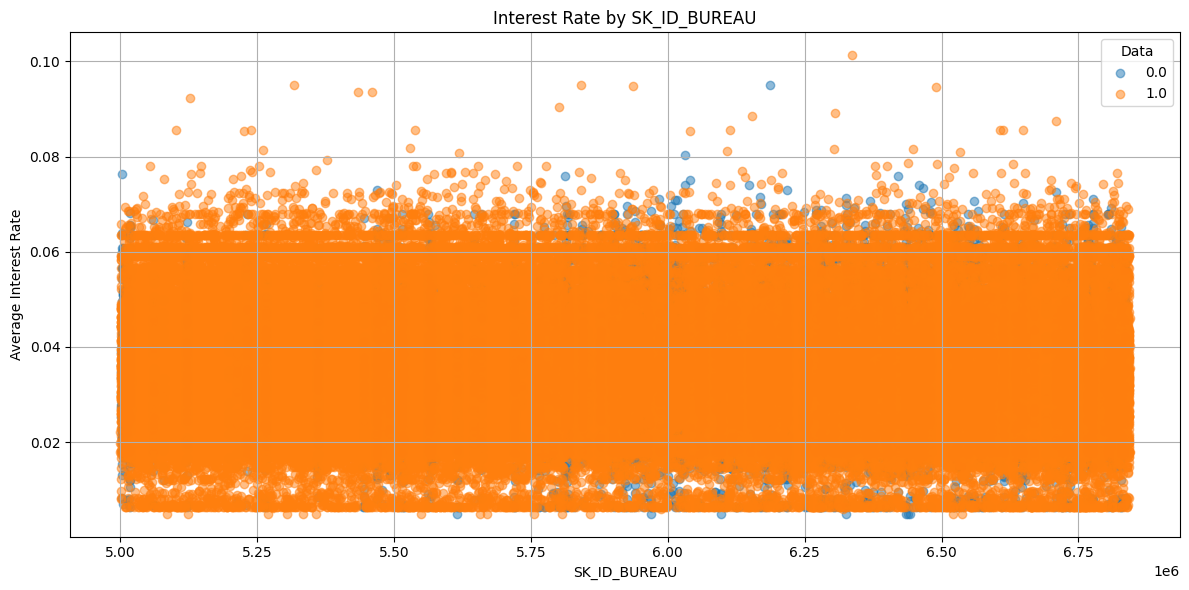

In [26]:
plt.figure(figsize=(12, 6))
for label, group in result.sample(n=100000).groupby("data"):
    plt.scatter(group["SK_ID_BUREAU"], group["interest_rate"], label=label, alpha=0.5)

plt.title("Interest Rate by SK_ID_BUREAU")
plt.xlabel("SK_ID_BUREAU")
plt.ylabel("Average Interest Rate")
plt.legend(title="Data")
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
cache_clear(globals())